In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
from models import CRW
from tqdm import tqdm

In [2]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
figsize = (12,9)

In [4]:
# generate 1000 CRW polymers of length 10-1000, and record their statistics
low=10
high=1000

num_crw = 100

rng = np.random.default_rng()
crw_list = [CRW(int(10**rng.uniform(np.log10(low),np.log10(high)))) for i in tqdm(range(num_crw))]

  2%|▏         | 2/100 [00:00<00:07, 13.77it/s]

100%|██████████| 100/100 [00:03<00:00, 30.06it/s]


In [5]:
print(crw_list)

[<models.CRW object at 0x7feec417d4f0>, <models.CRW object at 0x7fee598ef050>, <models.CRW object at 0x7fee598eee70>, <models.CRW object at 0x7fee598eecf0>, <models.CRW object at 0x7fee598eeed0>, <models.CRW object at 0x7fee598ef230>, <models.CRW object at 0x7fee598ef2f0>, <models.CRW object at 0x7fee598eedb0>, <models.CRW object at 0x7fee598ef590>, <models.CRW object at 0x7fee598ef0b0>, <models.CRW object at 0x7fee598ef410>, <models.CRW object at 0x7fee598ef830>, <models.CRW object at 0x7fee598ef7d0>, <models.CRW object at 0x7fee598ef9b0>, <models.CRW object at 0x7fee598ef650>, <models.CRW object at 0x7fee598ef5f0>, <models.CRW object at 0x7fee598efb30>, <models.CRW object at 0x7fee598efa10>, <models.CRW object at 0x7fee598ef890>, <models.CRW object at 0x7fee598efb90>, <models.CRW object at 0x7fee598efa70>, <models.CRW object at 0x7fee598efdd0>, <models.CRW object at 0x7fee598ef110>, <models.CRW object at 0x7fee598effb0>, <models.CRW object at 0x7fee598efe90>, <models.CRW object at 0x

In [6]:
crw_list[1].show()

CRW of length 848:
	Sigma: 1
	U_bb: 1
	e_rep: 1
Stats:
	Radius of Gyration: 17.799396514892578
	Total Potential Energy: 1.0770762060019479e-10
Residues:
(0.0, 0.0, 0.0)
(0.6752601861953735, -0.6892431974411011, -0.2626166343688965)
(1.1548609733581543, 0.1729263812303543, -0.09937852621078491)
(1.7456424236297607, -0.49538886547088623, 0.3526524603366852)
(1.8438441753387451, -0.8633139133453369, -0.5720029473304749)
(2.4344944953918457, -0.31886976957321167, -1.167580485343933)
(2.7814862728118896, 0.618443489074707, -1.1353232860565186)
(1.7916563749313354, 0.48741209506988525, -1.1907086372375488)
(0.8780352473258972, 0.3392162621021271, -1.5693039894104004)
(0.9634340405464172, 0.3164803087711334, -2.5653913021087646)


In [7]:
lengths = [crw.n for crw in tqdm(crw_list)]
R_gs = [float(crw.compute_rg()) for crw in tqdm(crw_list)]

print(lengths)
print(R_gs)

100%|██████████| 100/100 [00:00<00:00, 10682.31it/s]

[54, 848, 130, 101, 31, 12, 627, 420, 160, 165, 83, 193, 72, 10, 80, 72, 332, 131, 53, 174, 308, 609, 80, 265, 239, 17, 201, 91, 31, 34, 15, 759, 465, 415, 23, 15, 219, 47, 24, 38, 582, 41, 529, 842, 154, 252, 10, 11, 975, 45, 46, 52, 480, 60, 12, 119, 10, 79, 347, 28, 29, 41, 942, 25, 57, 211, 548, 542, 914, 449, 39, 359, 940, 25, 498, 24, 36, 12, 47, 87, 159, 94, 368, 833, 10, 69, 177, 101, 69, 696, 10, 727, 90, 12, 77, 37, 320, 257, 11, 563]
[3.452131509780884, 17.799396514892578, 7.20866584777832, 5.090195655822754, 2.304671049118042, 1.644206166267395, 21.314899444580078, 9.237082481384277, 6.053565979003906, 9.131031036376953, 5.676957130432129, 11.762829780578613, 5.01971960067749, 1.2619521617889404, 4.690202713012695, 3.6393489837646484, 10.966559410095215, 7.147919178009033, 3.2199668884277344, 7.841946601867676, 12.871821403503418, 13.864757537841797, 5.6073431968688965, 9.404251098632812, 7.920199871063232, 1.722382664680481, 6.6699137687683105, 4.46652364730835, 2.39542746

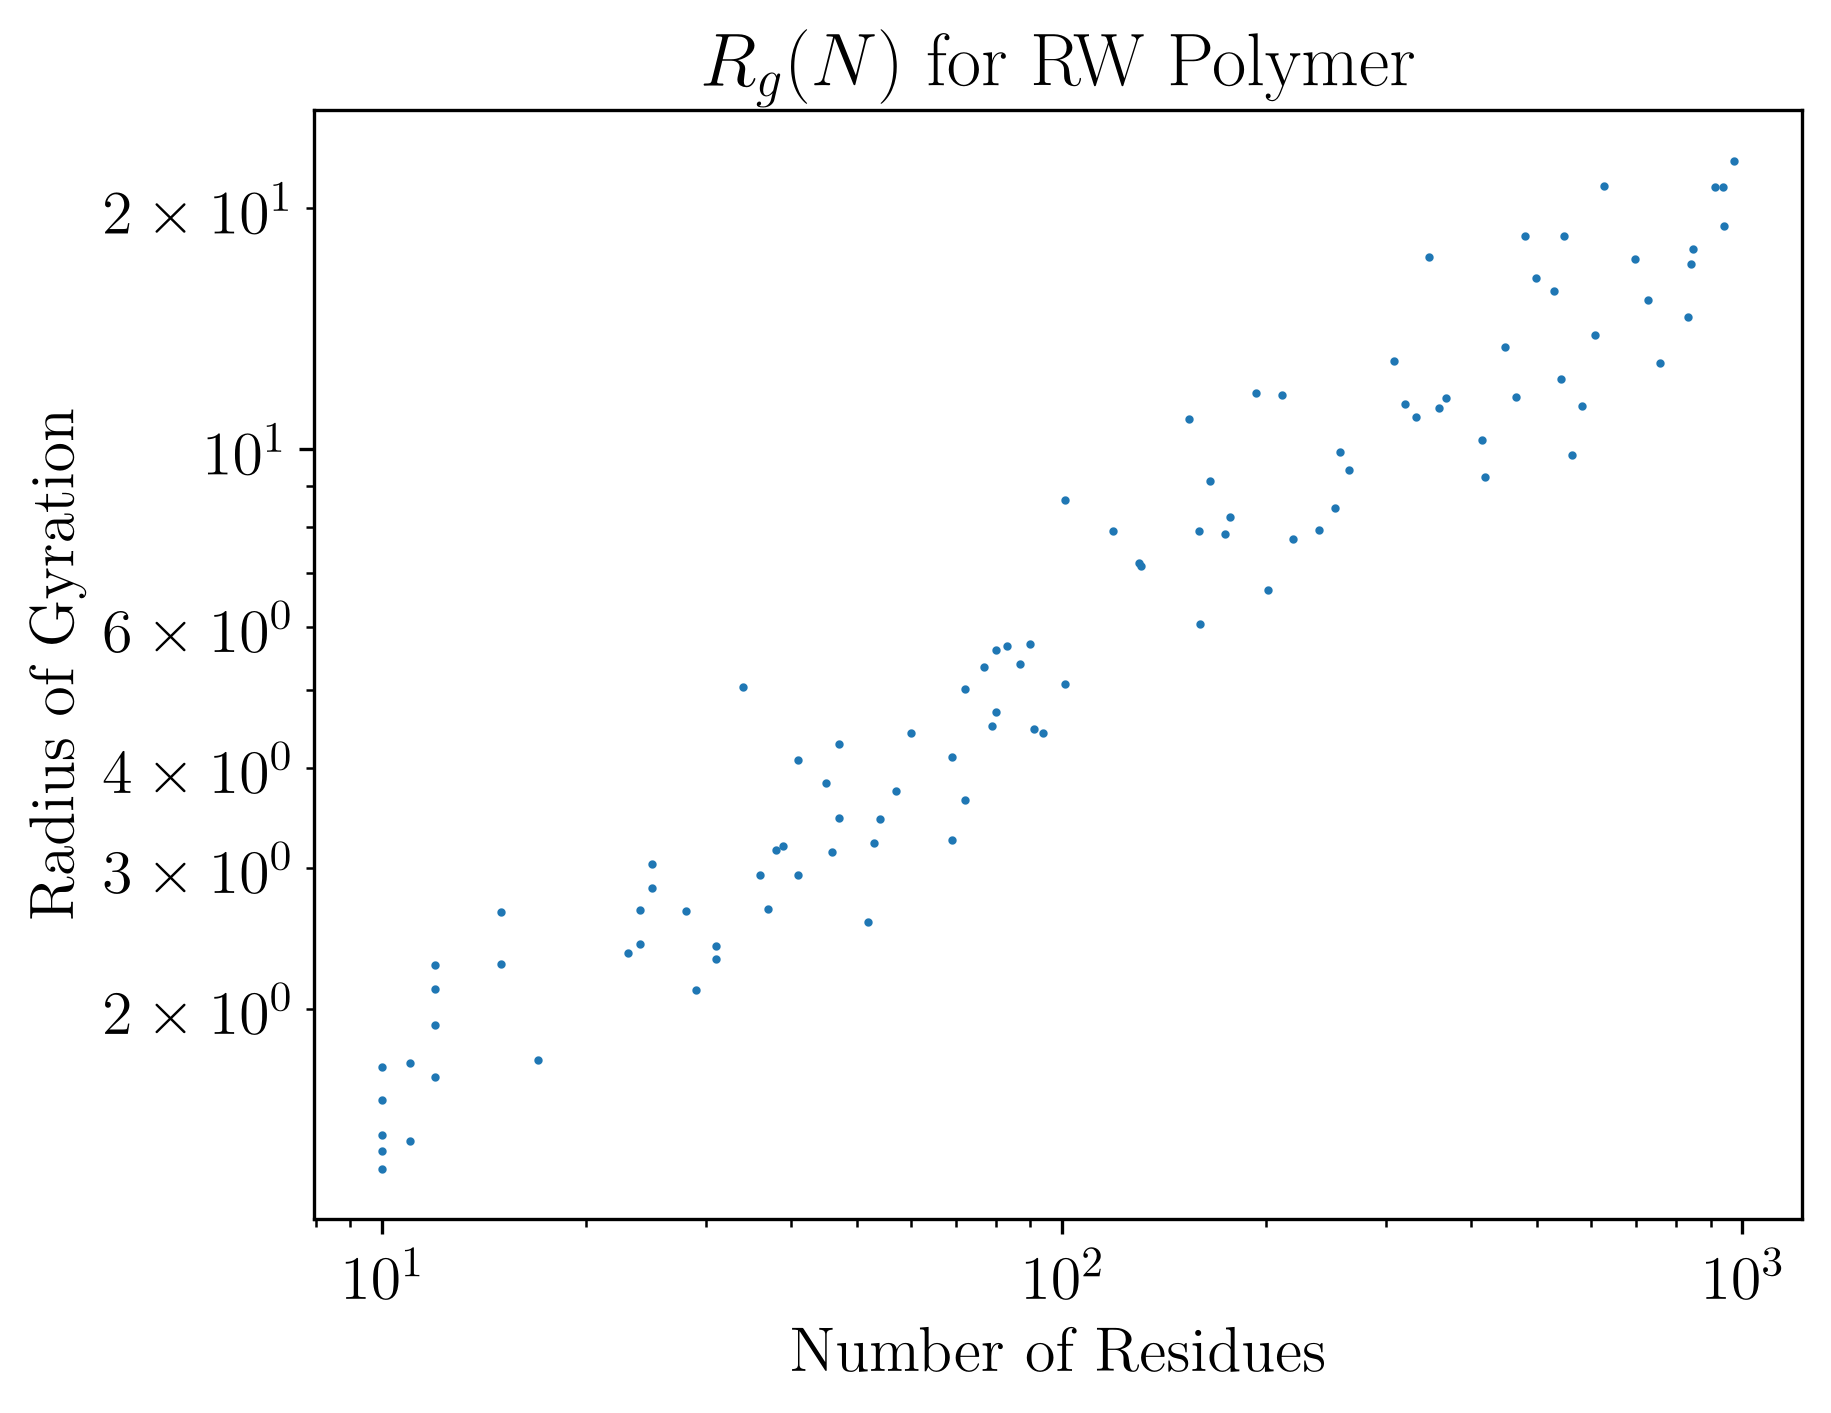

In [8]:
plt.figure()
plt.scatter(lengths, R_gs, s=1, label="Radius of Gyration")
plt.ylabel("Radius of Gyration")
plt.xlabel("Number of Residues")
plt.xscale("log")
plt.yscale("log")
plt.title(r"$R_g(N)$ for RW Polymer")
plt.savefig("RgVsN.png")

100%|██████████| 100/100 [02:33<00:00,  1.54s/it]
/tmp/ipykernel_43920/2695379395.py:26: RuntimeWarning: Mean of empty slice
  mean_Rg_n = np.nanmean(Rg_ns, axis=0)
/home/patrick/Projects/protein-folding/programs/Constrained-Polymer-Collapse/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


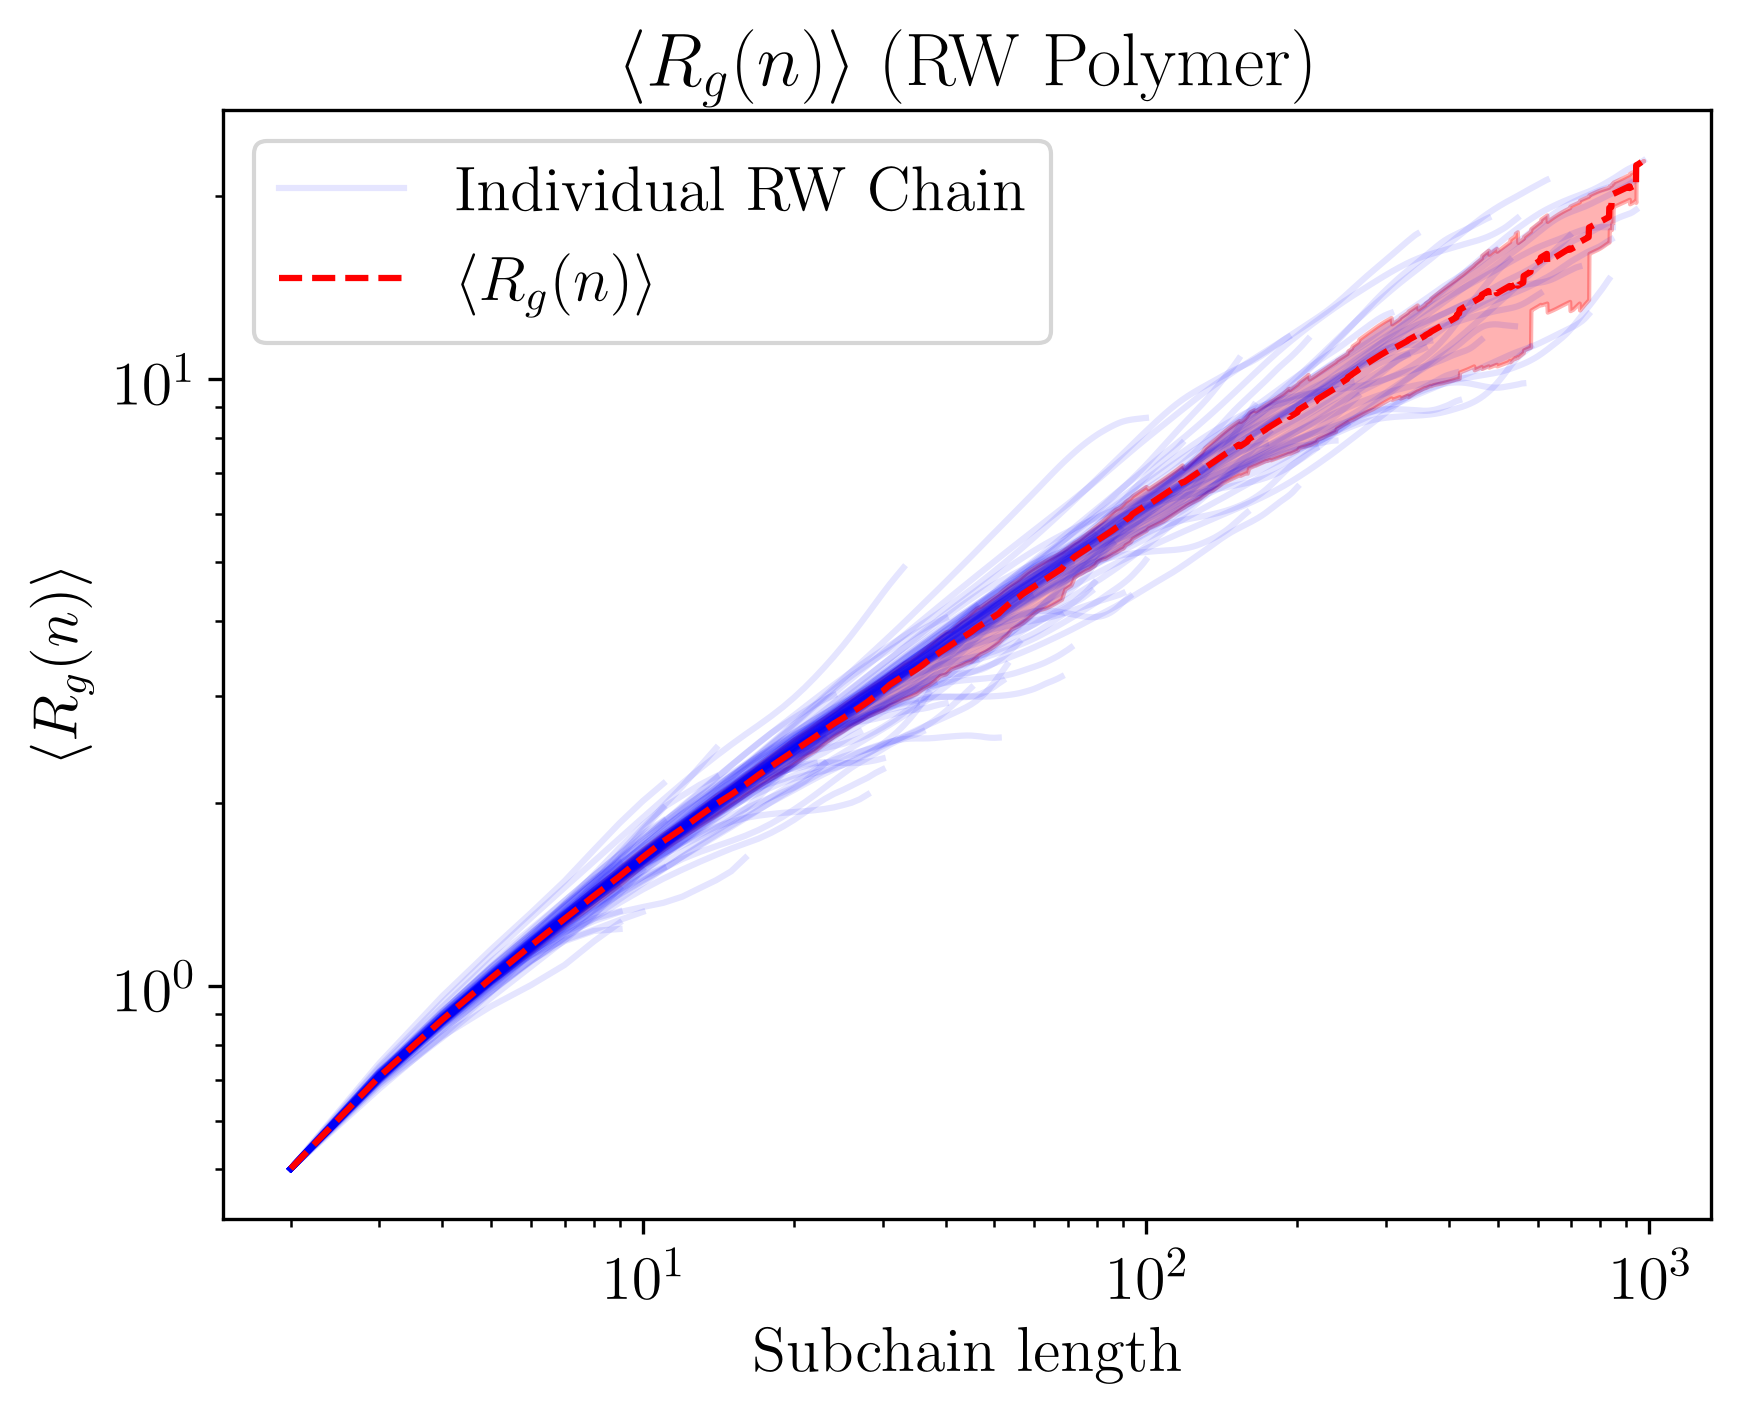

In [9]:
n_max = max(crw.n for crw in crw_list)

ns = np.arange(2, n_max+1)
Rg_ns = np.full((num_crw, len(ns)), np.nan)

plt.figure()
plt.title(r"$\langle R_g(n)\rangle$ (RW Polymer)")
plt.xlabel("Subchain length")
plt.ylabel(r"$\langle R_g(n) \rangle$")
plt.xscale("log")
plt.yscale("log")
for crw_idx, crw in enumerate(tqdm(crw_list)):
    
    valid_ns = ns[ns < crw.n]
     
    for n_idx, n in enumerate(valid_ns):
        Rg_ns[crw_idx, n_idx]=crw.compute_rg_n(n)
    plt.plot(
             valid_ns, 
             Rg_ns[crw_idx, :len(valid_ns)], 
             c="b", 
             alpha=.1, 
             label="Individual RW Chain" if crw_idx == 0 else "_nolegend_"
        )

mean_Rg_n = np.nanmean(Rg_ns, axis=0)
Rg_lo, Rg_hi = np.nanpercentile(Rg_ns, [16, 84], axis=0)

plt.plot(ns, mean_Rg_n, c="r", linestyle="--",label=r"$\langle R_g(n) \rangle$")
plt.fill_between(ns, Rg_lo, Rg_hi, color="r", alpha=.3)
plt.legend()
plt.savefig("Rg_n.png")
plt.show()

In [10]:
# Now when the polymers begin to fold what happens?
# First examine different central forces, and what they do to to final R_g(N) and the <R_g(n)> at different temperatures
# first output files to respective configs
for i, rw in enumerate(tqdm(crw_list)):
    rw.write_sim_config(f"../../input/rw_len_{rw.n}_no_{i}.txt")

100%|██████████| 100/100 [00:00<00:00, 571.44it/s]
